# Лабораторная работа №1. Создание предметного корпуса текстов

**Дисциплина:** Нейрокомпьютерные системы  
**Студент:** Акбаралыев А.  
**Вариант:** 5  
**Тема:** Тьютор по LSTM и управлению памятью  
**Ключевые слова:** LSTM, forget gate, input gate, long-term dependencies, gradient flow  
**Модель:** ai-forever/rugpt3small_based_on_gpt2 (125M параметров)  
**Язык корпуса:** Русский

## 1. Конфигурация и импорт

In [12]:
import json
import os
import re
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import Dataset, load_from_disk
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, set_seed

set_seed(42)


@dataclass
class LabConfig:
    """Конфигурация лабораторной работы."""

    # Вариант
    variant: int = 5
    topic: str = "Тьютор по LSTM и управлению памятью"
    keywords: list = field(
        default_factory=lambda: [
            "LSTM", "forget gate", "input gate",
            "long-term dependencies", "gradient flow",
        ]
    )

    # Модель
    model_name: str = "ai-forever/rugpt3small_based_on_gpt2"
    max_length: int = 512

    # Чанкинг
    chunk_size_words: int = 400
    chunk_overlap_words: int = 50

    # Пути
    dataset_dir: str = "corpus_variant_5"
    plot_path: str = "dataset_analysis.png"

    # Требования
    min_sources: int = 3
    min_chars: int = 50_000


config = LabConfig()

# Определение устройства
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Устройство: {device}")
print(f"Вариант: {config.variant}")
print(f"Тема: {config.topic}")
print(f"Модель: {config.model_name}")

Устройство: mps
Вариант: 5
Тема: Тьютор по LSTM и управлению памятью
Модель: ai-forever/rugpt3small_based_on_gpt2


## 2. Сбор корпуса текстов

Корпус состоит из 6 источников на русском языке, каждый посвящён отдельному аспекту LSTM.

In [13]:
sources = [
    {
        "title": "Архитектура LSTM: полное описание",
        "text": """Сети долгой краткосрочной памяти (Long Short-Term Memory, LSTM) представляют собой особый тип рекуррентных нейронных сетей, разработанный для решения проблемы долгосрочных зависимостей в последовательных данных. Архитектура LSTM была предложена Зеппом Хохрайтером и Юргеном Шмидхубером в 1997 году в статье «Long Short-Term Memory», опубликованной в журнале Neural Computation, и с тех пор стала одной из наиболее широко используемых моделей в области глубокого обучения для обработки последовательностей.

Историческая предпосылка создания LSTM заключалась в том, что традиционные рекуррентные нейронные сети (RNN) испытывали серьёзные трудности при обучении на длинных последовательностях. При обратном распространении ошибки через время (Backpropagation Through Time, BPTT) градиенты имели тенденцию либо экспоненциально затухать (vanishing gradient problem), либо экспоненциально возрастать (exploding gradient problem). Это делало невозможным эффективное обучение RNN для задач, требующих запоминания информации на протяжении сотен и тысяч временных шагов. Данная проблема была формально описана Бенжио, Симардом и Фраскони в 1994 году, которые показали теоретическую невозможность обучения стандартных RNN на длинных зависимостях.

Центральным элементом архитектуры LSTM является ячейка памяти (memory cell), которая представляет собой специальную структуру, способную хранить информацию в течение длительного времени. Состояние ячейки (cell state) передаётся вдоль цепочки с минимальными линейными взаимодействиями, что обеспечивает эффективный поток градиентов при обучении. Состояние ячейки можно представить как конвейерную ленту, проходящую через всю цепочку, на которую информация может добавляться или удаляться с помощью специальных механизмов — вентилей (gates). Эта аналогия помогает понять, почему LSTM способна сохранять информацию на протяжении длительных последовательностей: конвейерная лента движется с минимальным трением, и данные на ней остаются неизменными до тех пор, пока вентили явно не решат их изменить.

Каждая ячейка LSTM содержит три основных вентиля: вентиль забывания (forget gate), входной вентиль (input gate) и выходной вентиль (output gate). Каждый вентиль представляет собой сигмоидальный слой, за которым может следовать поэлементное умножение. Сигмоидальная функция активации на выходе вентиля возвращает значения в диапазоне от 0 до 1, где 0 означает полное блокирование информации, а 1 — полный пропуск информации. Такой механизм позволяет сети обучаться тому, какую информацию сохранять, какую отбрасывать и какую выводить на каждом временном шаге.

Математически работа LSTM-ячейки на временном шаге t описывается следующей системой уравнений. Вентиль забывания вычисляется по формуле: f_t = sigma(W_f * [h_{t-1}, x_t] + b_f), где sigma — сигмоидальная функция, W_f — весовая матрица вентиля забывания, h_{t-1} — скрытое состояние предыдущего шага, x_t — текущий входной вектор, b_f — вектор смещения. Вентиль забывания определяет, какую часть предыдущего состояния ячейки следует сохранить. Запись [h_{t-1}, x_t] означает конкатенацию двух векторов, что позволяет вентилю учитывать как предыдущее скрытое состояние, так и текущий вход при принятии решения.

Входной вентиль определяет, какая новая информация будет добавлена в состояние ячейки. Он вычисляется в два этапа. Сначала сигмоидальный слой решает, какие значения обновить: i_t = sigma(W_i * [h_{t-1}, x_t] + b_i). Затем слой гиперболического тангенса создаёт вектор кандидатов для обновления: C_tilde_t = tanh(W_C * [h_{t-1}, x_t] + b_C). Функция tanh ограничивает значения кандидатов в диапазоне [-1, 1], что помогает стабилизировать обучение и предотвращает неконтролируемый рост значений в состоянии ячейки.

Обновление состояния ячейки происходит по формуле: C_t = f_t * C_{t-1} + i_t * C_tilde_t. Здесь первое слагаемое отвечает за сохранение старой информации (контролируемое вентилем забывания), а второе — за добавление новой информации (контролируемое входным вентилем). Операция * обозначает поэлементное умножение (element-wise multiplication, или произведение Адамара). Именно аддитивный характер этого обновления является ключевым для решения проблемы затухающего градиента.

Выходной вентиль определяет, какая часть состояния ячейки будет использована в качестве выхода: o_t = sigma(W_o * [h_{t-1}, x_t] + b_o). Скрытое состояние текущего шага вычисляется как: h_t = o_t * tanh(C_t). Таким образом, выход проходит через функцию tanh (нормализуя значения в диапазон [-1, 1]) и затем фильтруется выходным вентилем. Скрытое состояние h_t используется как для формирования предсказания на текущем шаге, так и для передачи информации на следующий шаг.

Параметры LSTM-сети включают весовые матрицы и векторы смещения для каждого из трёх вентилей и слоя кандидатов. Общее количество обучаемых параметров одного LSTM-слоя составляет 4 * (n_h * (n_h + n_x) + n_h), где n_h — размерность скрытого состояния, n_x — размерность входного вектора. Множитель 4 соответствует четырём линейным преобразованиям: для forget gate, input gate, candidate state и output gate. Например, если n_h = 256 и n_x = 128, один LSTM-слой содержит 4 * (256 * (256 + 128) + 256) = 4 * 98,560 = 394,240 параметров.

В практических реализациях LSTM часто используются многослойные (stacked) конфигурации, где выход одного LSTM-слоя подаётся на вход следующего. Типичное количество слоёв — от 2 до 4. Также широко применяются двунаправленные (bidirectional) LSTM, обрабатывающие последовательность в обоих направлениях и объединяющие результаты. Двунаправленные LSTM удваивают число параметров, но позволяют каждому элементу последовательности использовать информацию как из прошлого, так и из будущего контекста.

Peephole-соединения — модификация LSTM, предложенная Герсом и Шмидхубером в 2000 году, при которой вентили получают доступ к состоянию ячейки напрямую, без прохождения через выходной вентиль. В peephole LSTM формулы вентилей модифицируются: f_t = sigma(W_f * [C_{t-1}, h_{t-1}, x_t] + b_f), что даёт вентилям дополнительную информацию для принятия решений.

Инициализация весов LSTM требует особого внимания. Смещение вентиля забывания обычно инициализируется положительным значением (например, 1.0), чтобы на начальных этапах обучения сеть была склонна запоминать информацию, а не забывать её. Это эмпирическое правило было предложено Йозефовичем и соавторами и показало значительное улучшение сходимости при обучении.

Архитектура LSTM послужила основой для многих последующих модификаций и упрощений. Наиболее известной из них является GRU (Gated Recurrent Unit), предложенная Кюнгхюном Чо в 2014 году, которая объединяет вентили забывания и входа в единый вентиль обновления и имеет меньше параметров при сопоставимом качестве на многих задачах. Другие варианты включают Minimal LSTM, Lightweight LSTM и различные архитектуры с дополнительными или модифицированными вентилями.

Реализация LSTM в современных фреймворках глубокого обучения существенно упрощает работу с этой архитектурой. В PyTorch LSTM реализована как модуль torch.nn.LSTM, принимающий параметры input_size, hidden_size, num_layers и дополнительные флаги (batch_first, dropout, bidirectional). Внутренне PyTorch использует оптимизированные CUDA-ядра (cuDNN) для максимальной производительности на GPU. В TensorFlow и Keras LSTM доступна через слой tf.keras.layers.LSTM с аналогичными параметрами. Обе реализации поддерживают автоматическое дифференцирование и интеграцию с другими слоями нейронной сети.

Масштабирование LSTM для практических приложений требует учёта нескольких факторов. Типичные размеры скрытого состояния варьируются от 128 для простых задач до 2048 для задач машинного перевода промышленного масштаба. Увеличение скрытого состояния квадратично увеличивает число параметров и вычислительные затраты. Поэтому на практике часто используются компромиссные подходы: увеличение числа слоёв вместо размера скрытого состояния, использование projection layer для проецирования выхода LSTM в пространство меньшей размерности, или факторизация весовых матриц для снижения вычислительной сложности без существенной потери качества.

Эволюция архитектуры LSTM продолжается и в современных исследованиях. Модели xLSTM (extended LSTM), предложенные в 2024 году, расширяют классическую архитектуру экспоненциальными вентилями и матричной памятью, достигая конкурентоспособных результатов с трансформерами на задачах языкового моделирования. Это показывает, что принципы, заложенные в оригинальной LSTM, остаются актуальными и продолжают развиваться спустя более чем 25 лет после первоначальной публикации.""",
    },
    {
        "title": "Forget Gate и Input Gate: механизмы управления памятью",
        "text": """Вентили забывания (forget gate) и входа (input gate) являются ключевыми компонентами архитектуры LSTM, обеспечивающими избирательное управление потоком информации через ячейку памяти. Понимание работы этих вентилей критически важно для эффективного применения LSTM-сетей и диагностики проблем при обучении.

Вентиль забывания (forget gate) был введён Феликсом Герсом, Юргеном Шмидхубером и Фредом Камминсом в 2000 году как дополнение к оригинальной архитектуре LSTM 1997 года. Первоначальная версия LSTM не имела механизма забывания, что могло приводить к неконтролируемому росту значений состояния ячейки. Forget gate решил эту проблему, позволив сети обучаться тому, какую информацию из прошлого следует отбросить. Эта модификация оказалась настолько важной, что сегодня LSTM с forget gate является стандартной версией архитектуры.

Математически forget gate вычисляется следующим образом: f_t = sigma(W_f * x_t + U_f * h_{t-1} + b_f), где f_t — вектор значений вентиля забывания размерности n_h (размер скрытого состояния), sigma — поэлементная сигмоидальная функция, W_f — весовая матрица размера n_h на n_x для входного вектора, U_f — весовая матрица размера n_h на n_h для предыдущего скрытого состояния, b_f — вектор смещения размерности n_h.

Каждый элемент вектора f_t принимает значение в диапазоне (0, 1). Значение, близкое к 1, означает, что соответствующий элемент состояния ячейки будет почти полностью сохранён. Значение, близкое к 0, означает, что этот элемент будет почти полностью забыт. Промежуточные значения обеспечивают частичное сохранение информации. Важно понимать, что forget gate работает поэлементно: разные компоненты состояния ячейки могут быть забыты или сохранены независимо друг от друга, что обеспечивает тонкий контроль над памятью сети.

Рассмотрим числовой пример работы forget gate. Предположим, что размерность скрытого состояния n_h = 4. Пусть на некотором временном шаге вентиль забывания выдал значения f_t = [0.9, 0.1, 0.8, 0.3], а текущее состояние ячейки C_{t-1} = [1.5, -2.0, 0.7, 3.1]. После применения вентиля забывания получаем: f_t * C_{t-1} = [0.9*1.5, 0.1*(-2.0), 0.8*0.7, 0.3*3.1] = [1.35, -0.2, 0.56, 0.93]. Видно, что первый и третий элементы были в основном сохранены (90% и 80% соответственно), а второй и четвёртый — значительно уменьшены (сохранено лишь 10% и 30%). Это демонстрирует, как forget gate выполняет избирательное забывание.

Входной вентиль (input gate) контролирует, какая новая информация будет записана в состояние ячейки. Он работает совместно с блоком вычисления кандидатов (candidate cell state). Формулы входного вентиля: i_t = sigma(W_i * x_t + U_i * h_{t-1} + b_i), и кандидат на обновление: C_tilde_t = tanh(W_c * x_t + U_c * h_{t-1} + b_c).

Входной вентиль i_t определяет степень обновления каждого элемента состояния ячейки. Кандидат C_tilde_t формирует предлагаемые новые значения в диапазоне [-1, 1] благодаря функции tanh. Произведение i_t * C_tilde_t даёт фактическое обновление, которое будет добавлено к состоянию ячейки. Разделение на input gate и candidate позволяет сети независимо контролировать, что записывать (candidate) и насколько сильно записывать (input gate).

Продолжая числовой пример: пусть i_t = [0.7, 0.9, 0.2, 0.6], C_tilde_t = [0.5, -0.8, 0.3, 0.9]. Тогда вклад входного вентиля: i_t * C_tilde_t = [0.35, -0.72, 0.06, 0.54]. Новое состояние ячейки: C_t = f_t * C_{t-1} + i_t * C_tilde_t = [1.35 + 0.35, -0.2 + (-0.72), 0.56 + 0.06, 0.93 + 0.54] = [1.70, -0.92, 0.62, 1.47]. Видно, что первый элемент увеличился (старое значение сохранено и добавлено новое), второй элемент изменил знак и уменьшился по модулю, третий остался почти без изменений (слабый input gate = 0.2), четвёртый значительно изменился.

Взаимодействие forget gate и input gate создаёт гибкий механизм управления памятью. Если forget gate полностью открыт (f=1) и input gate закрыт (i=0), ячейка просто передаёт своё предыдущее состояние без изменений — режим чистого запоминания. Если forget gate закрыт (f=0) и input gate открыт (i=1), старое состояние полностью стирается и заменяется новым — режим полной перезаписи. В промежуточных случаях ячейка выполняет взвешенную комбинацию старой и новой информации. Этот механизм можно сравнить с работой человеческой памяти: мы постоянно решаем, какую информацию стоит запомнить надолго, какую обновить, а какую забыть за ненадобностью.

При обучении LSTM-сети вентили обучаются автоматически посредством обратного распространения ошибки. Градиенты протекают через вентили, позволяя сети настраивать их поведение для конкретной задачи. Важно отметить, что благодаря аддитивному характеру обновления состояния ячейки (C_t = f_t * C_{t-1} + i_t * C_tilde_t) градиенты могут эффективно протекать через множество временных шагов, не затухая экспоненциально — это ключевое преимущество LSTM перед обычными RNN. Градиент dC_t/dC_{t-1} = f_t, и пока f_t достаточно близок к 1, градиент практически не теряется при прохождении через временной шаг.

Инициализация смещения вентиля забывания играет критическую роль в обучении. Стандартная рекомендация — инициализировать b_f значением от 1 до 2, что обеспечивает начальные значения f_t, близкие к 1 (из-за свойств сигмоидальной функции: sigma(1) ≈ 0.73, sigma(2) ≈ 0.88). Это означает, что на начальных этапах обучения сеть склонна сохранять информацию, а забывание будет постепенно обучаться по мере необходимости. Без этой инициализации сеть может преждевременно забывать важную информацию, что значительно замедляет или полностью блокирует обучение. Эксперименты показывают, что разница в скорости сходимости может составлять несколько порядков.

Визуализация активаций вентилей позволяет понять, какие паттерны в данных сеть научилась распознавать. Например, при обработке текста вентиль забывания часто активируется (значения близки к 0) при встрече знаков препинания, завершающих предложение, что соответствует интуитивному представлению о границах контекста. Входной вентиль, напротив, часто сильно активируется при появлении семантически значимых слов — существительных, глаголов, числовых значений. Такие визуализации полезны для отладки моделей и понимания того, какие аспекты входных данных модель считает важными.

В модифицированных архитектурах, таких как GRU, вентили забывания и входа объединены в единый вентиль обновления (update gate) z_t. Обновление состояния в GRU имеет вид: h_t = (1 - z_t) * h_{t-1} + z_t * h_tilde_t. Здесь коэффициент z_t одновременно контролирует и забывание ((1-z_t) играет роль forget gate), и запись (z_t играет роль input gate). Это упрощение сокращает количество параметров, но лишает модель возможности независимо контролировать забывание и запись.

Сопряжённое ограничение (coupled forget-input gate) — промежуточный вариант между полной LSTM и GRU, где i_t = 1 - f_t. Это сокращает число параметров при сохранении разделения состояний. Такой подход используется в некоторых практических реализациях, когда вычислительные ресурсы ограничены, но требуется архитектура с явным состоянием ячейки. На практике coupled gate часто показывает результаты, сопоставимые с полной LSTM, что свидетельствует об избыточности некоторых параметров в стандартной архитектуре.

Аблационные исследования (ablation studies) вентилей LSTM проводились Грефом и другими в 2017 году. Они систематически отключали различные компоненты LSTM и оценивали влияние на качество модели. Результаты показали, что forget gate является наиболее критическим компонентом — его удаление приводит к наибольшему падению качества. Input gate занимает второе место по важности. Output gate оказался наименее критичным — его удаление лишь незначительно снижало качество на большинстве задач. Эти результаты объясняют, почему GRU, сохраняющая аналог forget gate, работает сопоставимо с полной LSTM.

Выходной вентиль (output gate) заслуживает отдельного обсуждения. Он вычисляется по формуле o_t = sigma(W_o * x_t + U_o * h_{t-1} + b_o), и используется для формирования скрытого состояния: h_t = o_t * tanh(C_t). Output gate позволяет ячейке хранить информацию в состоянии ячейки, не обязательно выводя её на каждом шаге. Это полезно, когда информация нужна не немедленно, а через несколько шагов в будущем.

Практическое значение правильной настройки вентилей подтверждается многочисленными экспериментами. При обработке естественного языка исследователи обнаружили, что забывающий вентиль обучается характерным паттернам: значения f_t близки к нулю на границах предложений и абзацев, а значения, близкие к единице, наблюдаются внутри синтаксических конструкций. Входной вентиль проявляет сильную активацию при появлении ключевых слов, таких как имена собственные, числительные и глаголы. Эти паттерны устойчиво воспроизводятся при обучении на различных корпусах и языках, что свидетельствует о том, что LSTM обучается фундаментальным лингвистическим закономерностям.""",
    },
    {
        "title": "Проблема затухающего градиента и LSTM как решение",
        "text": """Проблема затухающего градиента (vanishing gradient problem) является фундаментальным препятствием при обучении глубоких нейронных сетей, особенно рекуррентных, и именно для её решения была разработана архитектура LSTM. Понимание этой проблемы необходимо для осознания того, почему LSTM-сети оказались столь успешными в задачах обработки последовательностей.

При обучении нейронной сети методом обратного распространения ошибки градиенты функции потерь вычисляются по цепному правилу дифференцирования. В случае рекуррентной сети градиент должен пропагироваться через все временные шаги от момента вычисления потерь до ранних элементов последовательности. Этот процесс называется обратным распространением через время (Backpropagation Through Time, BPTT). BPTT фактически «разворачивает» рекуррентную сеть во времени, создавая эквивалент глубокой сети с числом слоёв, равным длине последовательности, и применяет к ней стандартный алгоритм обратного распространения.

Для простой RNN с функцией активации tanh скрытое состояние вычисляется как: h_t = tanh(W_hh * h_{t-1} + W_xh * x_t + b_h). При вычислении градиента по цепному правилу получается произведение якобианов: dL/dh_k = dL/dh_T * prod_{t=k+1}^{T} (dh_t/dh_{t-1}). Каждый сомножитель dh_t/dh_{t-1} = diag(1 - tanh^2(z_t)) * W_hh, где z_t — аргумент tanh на шаге t.

Ключевая проблема заключается в том, что при T-k больших (длинная последовательность или большое расстояние между зависимыми элементами) произведение множителей ведёт себя экспоненциально. Если наибольшее сингулярное значение матрицы W_hh меньше 1 (что типично при стандартной инициализации), произведение стремится к нулю — градиенты затухают (vanishing gradient). Если наибольшее сингулярное значение больше 1, произведение растёт неограниченно — градиенты взрываются (exploding gradient). Граница между этими режимами определяется спектральным радиусом матрицы рекуррентных весов.

Затухающие градиенты имеют практическое следствие: сеть не способна обучиться зависимостям между элементами, разделёнными большим числом временных шагов. Информация из ранних частей последовательности фактически не влияет на обновление весов, поскольку соответствующие градиенты пренебрежимо малы. Это делает обычные RNN неспособными решать задачи с долгосрочными зависимостями (long-term dependencies). Хохрайтер показал, что даже для последовательностей длиной 10-20 шагов градиенты в простой RNN могут затухать на несколько порядков.

Примеры задач, требующих долгосрочных зависимостей: определение тональности длинного текста, где ключевое слово находится в начале, а оценка даётся в конце; перевод предложений с дальними согласованиями (например, согласование подлежащего и сказуемого через длинное придаточное предложение); прогнозирование временных рядов с сезонными паттернами; генерация музыки с сохранением тональности на протяжении всего произведения; анализ длинных диалогов, где контекст из начала разговора важен для понимания последних реплик.

LSTM решает проблему затухающего градиента благодаря нескольким архитектурным особенностям. Первая и главная — аддитивное обновление состояния ячейки: C_t = f_t * C_{t-1} + i_t * C_tilde_t. В отличие от мультипликативного обновления в обычной RNN (h_t = tanh(W*h_{t-1} + ...)), аддитивная связь обеспечивает более прямой путь для потока градиентов. Можно провести аналогию с электрической цепью: в RNN сигнал проходит через нелинейный элемент на каждом шаге, теряя энергию, а в LSTM существует прямой провод (состояние ячейки), по которому сигнал проходит с минимальными потерями.

Рассмотрим поток градиента через состояние ячейки. Градиент dC_t/dC_{t-1} = f_t (забывающий вентиль). Если forget gate близок к 1 (что обеспечивается правильной инициализацией), градиент почти не затухает при прохождении через временной шаг. Через k шагов: dC_T/dC_{T-k} = prod_{t=T-k+1}^{T} f_t. Даже если некоторые f_t значительно меньше 1, пока произведение остаётся достаточно большим, градиент эффективно пропагируется. Это кардинально отличается от ситуации в обычной RNN, где каждый множитель содержит производную tanh (всегда меньше 1) и матрицу весов.

Вторая важная особенность — отсутствие нелинейности на прямом пути состояния ячейки. В обычной RNN каждый временной шаг применяет нелинейную функцию tanh к скрытому состоянию, что дополнительно сжимает градиенты (производная tanh меньше 1 повсюду, кроме нуля, и стремится к 0 при больших аргументах). В LSTM состояние ячейки обновляется линейно (умножение на f_t и сложение), нелинейность tanh применяется только при вычислении выхода (h_t = o_t * tanh(C_t)), но не на основном пути пропагации градиента.

Третья особенность — обучаемое забывание. В отличие от фиксированного затухания (как в RNN, где W_hh фиксирована в пределах одного обновления), LSTM может адаптивно выбирать, когда забывать и когда сохранять информацию. Забывающий вентиль зависит от текущего входа и предыдущего состояния, что позволяет сети принимать контекстно-зависимые решения о управлении памятью. Например, при чтении текста модель может научиться забывать контекст предыдущего предложения при встрече с точкой и началом нового предложения.

Эмпирические исследования подтверждают эффективность LSTM в сохранении градиентов. Классический эксперимент — задача запоминания последовательности (sequence memorization): модель должна запомнить первый элемент последовательности и воспроизвести его через T шагов. Обычная RNN перестаёт справляться с этой задачей при T больше 10-20, тогда как LSTM успешно работает при T = 1000 и более. Это демонстрирует принципиальное различие в способности сохранять информацию на длинных дистанциях.

Визуализация потока градиентов (gradient flow) в LSTM показывает характерную картину: градиенты по состоянию ячейки остаются относительно стабильными на протяжении всей последовательности, в то время как в обычной RNN они экспоненциально затухают. Это можно наблюдать, построив график нормы градиента dL/dh_t как функции t для обоих типов сетей на одной и той же задаче. Стабильность градиентов в LSTM не означает, что они абсолютно постоянны — они могут варьироваться в зависимости от значений forget gate, но их порядок величины сохраняется на протяжении всей последовательности.

Помимо LSTM, существуют и другие методы борьбы с затухающими градиентами: gradient clipping (обрезка градиентов по норме) предотвращает взрыв градиентов, но не решает проблему затухания; ортогональная инициализация весов обеспечивает начальные сингулярные значения W_hh, равные 1; skip connections (residual connections) в глубоких RNN обеспечивают альтернативные пути для градиентов; нормализация (batch normalization, layer normalization) стабилизирует распределения активаций.

Однако именно LSTM предложила наиболее элегантное и полное решение, позволяющее сети самой обучаться управлению потоком информации и градиентов. Это объясняет, почему LSTM оставались доминирующей архитектурой для обработки последовательностей на протяжении почти двух десятилетий — с 1997 года до появления трансформеров в 2017 году.

Количественная оценка затухания градиентов может быть выполнена с помощью вычисления отношения norm(dL/dh_1) / norm(dL/dh_T) для последовательности длины T. В обычной RNN это отношение экспоненциально мало: для типичных параметров оно составляет порядка 10^{-5} уже при T = 50. В LSTM это отношение обычно остаётся в пределах 10^{-1} — 10^{0} при тех же длинах последовательностей, что подтверждает эффективность механизма управления памятью.

Связь между LSTM и residual connections (skip connections) заслуживает внимания. Обновление состояния ячейки C_t = f_t * C_{t-1} + i_t * C_tilde_t при f_t = 1 и i_t, близком к 0, превращается в тождественное отображение C_t ≈ C_{t-1}, аналогичное skip connection в ResNet. Таким образом, LSTM можно рассматривать как рекуррентную сеть со встроенными обучаемыми skip connections, где степень пропуска определяется вентилем забывания. Эта аналогия была формально исследована в работах по Highway Networks, которые обобщают идею вентильного механизма на нерекуррентные сети.

Четвёртая особенность LSTM — наличие выходного вентиля, который обеспечивает дополнительный контроль над тем, какая информация из состояния ячейки используется для формирования выхода и передачи на следующий шаг. Это позволяет состоянию ячейки хранить информацию, которая не проявляется непосредственно в текущем выходе, но может быть использована в будущем. Такой механизм обеспечивает ещё более гибкое управление потоком информации и дополнительно стабилизирует обучение.""",
    },
    {
        "title": "LSTM vs обычная RNN: детальное сравнение архитектур",
        "text": """Сравнение архитектур LSTM и обычной рекуррентной нейронной сети (vanilla RNN) позволяет глубже понять преимущества и ограничения каждого подхода. Обе архитектуры относятся к семейству рекуррентных нейронных сетей и предназначены для обработки последовательных данных, однако существенно различаются по структуре, возможностям и области применения.

Обычная RNN имеет простую архитектуру: на каждом временном шаге t вычисляется скрытое состояние h_t = tanh(W_xh * x_t + W_hh * h_{t-1} + b_h), а выход y_t = W_hy * h_t + b_y. Здесь единственное скрытое состояние h_t выполняет одновременно две функции: хранение долговременной информации и формирование текущего выхода. Это создаёт фундаментальный конфликт: для точного предсказания на текущем шаге скрытое состояние должно содержать релевантную информацию, но при этом оно же является единственным каналом передачи информации между временными шагами. Можно провести аналогию: это как если бы человек мог записывать заметки только на одном листке бумаги, каждый раз стирая предыдущие записи.

LSTM разделяет эти две функции, вводя отдельное состояние ячейки C_t для долговременного хранения и скрытое состояние h_t для формирования выхода. Состояние ячейки обновляется аддитивно и контролируется вентилями, а скрытое состояние является отфильтрованной версией состояния ячейки. Это разделение является ключевым архитектурным преимуществом LSTM, аналогичным тому, как человек может иметь долговременную память (записная книжка) и оперативную память (текущие мысли).

Сравнение количества параметров: для vanilla RNN с размерностью входа n_x и скрытого состояния n_h общее число параметров одного слоя: n_h * (n_x + n_h) + n_h = n_h * (n_x + n_h + 1). Для LSTM число параметров: 4 * [n_h * (n_x + n_h) + n_h] = 4 * n_h * (n_x + n_h + 1), то есть ровно в 4 раза больше (по одному набору параметров на каждый из 3 вентилей плюс candidate state). Например, при n_x = 128 и n_h = 256: vanilla RNN имеет 256 * (128 + 256 + 1) = 98,560 параметров, а LSTM — 394,240 параметров.

Поток градиентов — главное различие в контексте обучаемости. В vanilla RNN градиент по скрытому состоянию: dh_t/dh_{t-1} = diag(1 - tanh^2(z_t)) * W_hh. Спектральный радиус этой матрицы определяет поведение градиентов при пропагации через множество шагов. Если спектральный радиус меньше 1, градиенты экспоненциально затухают, если больше 1 — экспоненциально растут. В LSTM градиент по состоянию ячейки: dC_t/dC_{t-1} = diag(f_t), где f_t — вентиль забывания. Поскольку значения f_t обучаемы и обычно близки к 1, градиент затухает значительно медленнее.

Способность к запоминанию кардинально различается. В классическом эксперименте с копированием последовательности (copy task) модель должна запомнить входную последовательность и воспроизвести её после определённой задержки (delay). Результаты эксперимента: vanilla RNN — максимальная задержка при успешном обучении составляет 10-20 шагов, LSTM — успешно работает с задержками 100-1000 шагов и более, GRU — результаты сопоставимы с LSTM на средних задержках (до 200-300 шагов), но уступают на очень длинных.

Скорость обучения и сходимость также различаются. Vanilla RNN обучается быстрее на каждом шаге (меньше вычислений), но часто требует значительно больше эпох для достижения сопоставимого качества. LSTM медленнее на каждом шаге обучения, но обычно сходится за меньшее число эпох. На практике общее время обучения LSTM часто оказывается меньше, чем для vanilla RNN на задачах с длинными зависимостями. Исследования показывают, что для задач с зависимостями длиной более 20-30 шагов LSTM обучается стабильнее и предсказуемее.

Вычислительная сложность на один временной шаг: vanilla RNN — O(n_h^2 + n_h * n_x), LSTM — O(4 * (n_h^2 + n_h * n_x)), то есть примерно в 4 раза выше. На практике это компенсируется лучшей параллелизуемостью: все 4 линейных преобразования в LSTM могут быть объединены в одну матрицу и вычислены одной операцией умножения. Также существуют оптимизированные реализации (cuDNN LSTM, fused LSTM), которые значительно сокращают разрыв в скорости.

Потребление памяти: LSTM требует хранения как скрытого состояния h_t, так и состояния ячейки C_t на каждом временном шаге (для обратного распространения), что удваивает требования к памяти по сравнению с vanilla RNN. При обучении на длинных последовательностях это может стать ограничивающим фактором. Technique gradient checkpointing позволяет снизить потребление памяти ценой дополнительных вычислений.

Интерпретируемость является неожиданным преимуществом LSTM. Благодаря явным вентилям можно визуализировать, какие элементы последовательности сеть решает запомнить (input gate), забыть (forget gate) или вывести (output gate). В vanilla RNN нет такого чёткого разделения функций, что затрудняет интерпретацию работы сети. Визуализация активаций вентилей LSTM широко используется в исследовательских работах для анализа поведения модели.

Области применения: vanilla RNN подходит для задач с короткими зависимостями и ограниченными вычислительными ресурсами — например, простая классификация коротких текстов, предсказание следующего символа в коротких строках. LSTM предпочтительна для задач с длинными зависимостями — машинный перевод, генерация текстов, распознавание речи, анализ временных рядов, генерация музыки.

Современный контекст: с появлением архитектуры трансформер (Transformer) в 2017 году и моделей типа BERT и GPT, LSTM постепенно уступает позиции в задачах обработки естественного языка. Однако LSTM сохраняет преимущества в задачах с ограниченным объёмом данных, при потоковой обработке (streaming), где данные поступают поэлементно, и в системах с жёсткими ограничениями по памяти и вычислениям. Также LSTM остаётся актуальной в области обработки временных рядов, сигналов и встраиваемых систем.

Важно отметить, что GRU (Gated Recurrent Unit) занимает промежуточную позицию между vanilla RNN и LSTM. GRU имеет 3 * n_h * (n_x + n_h + 1) параметров (в 3 раза больше RNN, но на 25% меньше LSTM). GRU не имеет отдельного состояния ячейки, что упрощает архитектуру, но может ограничивать её выразительность на задачах, требующих очень длительного хранения информации. Эмпирически GRU и LSTM показывают сопоставимые результаты на большинстве практических задач, и выбор между ними часто определяется вычислительными ограничениями.

Таблица сравнительных характеристик помогает обобщить различия между архитектурами. По критерию количества параметров на слой: vanilla RNN — n_h*(n_x+n_h+1), LSTM — 4*n_h*(n_x+n_h+1), GRU — 3*n_h*(n_x+n_h+1). По способности к долгосрочному запоминанию: vanilla RNN — низкая (10-20 шагов), LSTM — высокая (1000+ шагов), GRU — средне-высокая (200-500 шагов). По наличию отдельного состояния ячейки: vanilla RNN — нет, LSTM — да (C_t), GRU — нет. По количеству вентилей: vanilla RNN — 0, LSTM — 3 (forget, input, output), GRU — 2 (reset, update). По интерпретируемости: vanilla RNN — низкая, LSTM — высокая (визуализация вентилей), GRU — средняя. По вычислительной эффективности: vanilla RNN — наивысшая, LSTM — наименьшая, GRU — промежуточная.

Практические рекомендации по выбору архитектуры: если задача требует обработки последовательностей длиной менее 20-30 элементов и вычислительные ресурсы ограничены, vanilla RNN может быть достаточной. Для задач с длинными зависимостями (50-1000 шагов) следует выбирать между LSTM и GRU. LSTM предпочтительна, когда важна интерпретируемость модели или когда задача требует очень длительного хранения информации. GRU является хорошим выбором по умолчанию, когда вычислительные ресурсы ограничены, а длина зависимостей умеренная. Для задач NLP с большими объёмами данных трансформеры обычно превосходят оба варианта рекуррентных архитектур.

Гибридные архитектуры, сочетающие LSTM с другими типами слоёв, часто показывают лучшие результаты, чем чистые LSTM или чистые трансформеры. Например, архитектура CNN-LSTM сначала извлекает локальные признаки свёрточными слоями, а затем моделирует временные зависимости с помощью LSTM. Такой подход успешно применяется в задачах анализа видео, обработки аудио и прогнозирования временных рядов с мультимодальными входами.""",
    },
    {
        "title": "Практические применения LSTM-сетей",
        "text": """Сети LSTM нашли широкое применение в самых разнообразных областях, где требуется обработка последовательных данных и учёт долгосрочных зависимостей. Рассмотрим основные области применения, конкретные задачи и архитектурные решения, используемые на практике.

Обработка естественного языка (NLP) стала одной из первых областей, где LSTM продемонстрировали значительное превосходство над традиционными методами. В задаче машинного перевода архитектура sequence-to-sequence (seq2seq) с LSTM-энкодером и LSTM-декодером, предложенная Сатскивером, Виньялсом и Ле в 2014 году, совершила прорыв. Энкодер обрабатывает входное предложение и формирует вектор контекста — фиксированной размерности представление всего предложения. Декодер генерирует перевод по одному слову, используя этот вектор контекста и свои предыдущие предсказания. Размер скрытого состояния обычно составляет 512-1024, количество слоёв — 2-4. Данная модель легла в основу Google Neural Machine Translation (GNMT), обслуживавшей миллиарды запросов до перехода на трансформерную архитектуру.

Механизм внимания (attention mechanism), предложенный Бахданау и соавторами в 2015 году, значительно улучшил качество LSTM-переводчиков. Вместо использования единственного вектора контекста, attention позволяет декодеру на каждом шаге «обращать внимание» на разные части входного предложения. Это особенно важно для длинных предложений, где единственный вектор контекста не может вместить всю необходимую информацию.

Языковое моделирование — задача предсказания следующего слова или символа в последовательности — является ещё одним классическим применением LSTM. Языковые модели на основе LSTM используются для оценки вероятности текстов (perplexity), генерации текста, автодополнения ввода. Модель AWD-LSTM (Averaged Stochastic Gradient Descent Weight-Dropped LSTM), предложенная Мериттом и другими, долгое время удерживала лидирующие позиции в бенчмарках языкового моделирования Penn Treebank и WikiText, достигая perplexity ниже 60 на PTB.

Анализ тональности (sentiment analysis) текстов является одним из ключевых применений LSTM в коммерческих системах. Двунаправленная LSTM (BiLSTM) обрабатывает текст в обоих направлениях, объединяя информацию из левого и правого контекста. Это особенно важно для понимания тональности, так как смысл слова часто зависит от окружающего контекста. Например, в предложении «Этот фильм не был плохим» слово «плохим» приобретает положительную коннотацию благодаря отрицанию «не». LSTM способна уловить эту зависимость между отрицанием и прилагательным даже на значительном расстоянии.

Именованные сущности (Named Entity Recognition, NER) и другие задачи маркировки последовательностей (sequence labeling) эффективно решаются архитектурой BiLSTM-CRF. LSTM-слой извлекает контекстуальные признаки, а CRF (Conditional Random Field) на выходе обеспечивает согласованность меток (например, после B-PER должно следовать I-PER, а не I-LOC). Эта архитектура была стандартом до появления BERT и показывала state-of-the-art результаты на бенчмарках CoNLL-2003 и OntoNotes.

Распознавание речи (Automatic Speech Recognition, ASR) активно использует LSTM-сети. Акустическая модель принимает на вход спектрограмму или мел-кепстральные коэффициенты (MFCC) и выдаёт последовательность фонем или символов. Глубокие двунаправленные LSTM с 5-7 слоями достигают высокого качества распознавания. Компания Baidu в системе Deep Speech 2 использовала 7-слойную RNN/LSTM архитектуру с CTC (Connectionist Temporal Classification) критерием. Apple Siri и Google Voice также использовали LSTM-модели в своих системах распознавания речи на протяжении многих лет.

Синтез речи (Text-to-Speech, TTS) также применяет LSTM для генерации акустических параметров из текста. Модель WaveRNN, представленная DeepMind, использовала LSTM для поэлементной генерации аудиосигнала с высоким качеством. Хотя современные TTS-системы всё чаще используют трансформеры и диффузионные модели, LSTM-подходы остаются актуальными для систем с ограниченными ресурсами, например в мобильных устройствах и встраиваемых системах.

Прогнозирование временных рядов (time series forecasting) — область, где LSTM-сети остаются конкурентоспособными и активно используются. Задачи включают: прогнозирование финансовых рынков (цены акций, курсы валют), прогноз энергопотребления, прогноз спроса в ритейле, прогноз погоды, мониторинг состояния промышленного оборудования (predictive maintenance). LSTM хорошо подходят для временных рядов благодаря способности автоматически извлекать сезонные паттерны, тренды и нелинейные зависимости без необходимости ручного проектирования признаков.

Типичная архитектура для прогнозирования временных рядов: входной слой принимает окно из последних N наблюдений (например, 30 дней); 1-2 слоя LSTM с размерностью 64-256; полносвязный слой для формирования прогноза на один или несколько шагов вперёд. Вариант encoder-decoder используется для прогнозирования множественных шагов: энкодер обрабатывает историю, декодер генерирует прогноз на горизонт планирования.

Генерация музыки — творческое применение LSTM, демонстрирующее способность к захвату сложных паттернов. LSTM обучается на MIDI-представлениях музыкальных произведений и генерирует новые мелодии. Модель должна учитывать гармонию (одновременное звучание нот), ритм и структуру произведения на различных временных масштабах — от отдельных нот до музыкальных фраз и разделов. Проект Magenta от Google использовал LSTM для генерации мелодий и создания интерактивных музыкальных инструментов.

Аномальное обнаружение (anomaly detection) в последовательностях — ещё одно важное применение. LSTM обучается на нормальных данных и предсказывает ожидаемое поведение. Значительное отклонение фактических данных от предсказаний сигнализирует об аномалии. Это применяется в кибербезопасности (обнаружение вторжений), мониторинге серверов, контроле качества производства и медицинской диагностике (мониторинг ЭКГ и других физиологических сигналов).

Управление роботами и автономные системы также используют LSTM для обработки сенсорных данных во времени. LSTM-сети способны интегрировать показания различных датчиков (камеры, лидар, инерциальные измерительные блоки) на протяжении длительных временных промежутков, формируя устойчивое представление о динамическом окружении. В задачах навигации LSTM помогает учитывать историю перемещений для более точного планирования маршрута. Компания Tesla в ранних версиях системы Autopilot использовала LSTM-модули для обработки последовательностей видеокадров.

Биоинформатика представляет ещё одну важную область применения LSTM. Анализ последовательностей ДНК и белков естественным образом формулируется как задача обработки последовательностей. LSTM-сети применяются для предсказания структуры белков, классификации генов, идентификации функциональных регионов в геноме и предсказания взаимодействий между белками. Способность LSTM учитывать дальние зависимости особенно важна, поскольку функциональные элементы в биологических последовательностях могут быть разделены тысячами позиций.

Описание изображений (image captioning) — задача на стыке компьютерного зрения и NLP, где LSTM используется для генерации текстовых описаний изображений. Типичная архитектура состоит из свёрточной сети (например, ResNet или VGG) в качестве энкодера изображения и LSTM-декодера для генерации описания. Модель Show and Tell от Google стала одной из первых успешных систем автоматического описания изображений, а модель Show, Attend and Tell добавила механизм визуального внимания, позволяющий модели фокусироваться на разных частях изображения при генерации каждого слова описания.""",
    },
    {
        "title": "Обучение LSTM-сетей: практические аспекты",
        "text": """Обучение сетей LSTM требует учёта множества практических аспектов, от инициализации весов до выбора оптимизатора и стратегий регуляризации. Правильная настройка этих гиперпараметров и техник существенно влияет на качество модели и скорость обучения.

Инициализация весов является первым критическим шагом. Для весовых матриц вентилей (W_f, W_i, W_o) и кандидатов (W_c) обычно применяется ортогональная инициализация для рекуррентных весов (U) и инициализация Ксавье (Xavier/Glorot) для входных весов (W). Ортогональная инициализация обеспечивает сохранение нормы градиента при прохождении через рекуррентные соединения, что критически важно для стабильного обучения. Математически ортогональная матрица Q удовлетворяет условию Q^T * Q = I, что означает, что при умножении вектора на Q его норма сохраняется. Инициализация Ксавье масштабирует веса пропорционально 1/sqrt(n_in + n_out), обеспечивая стабильные дисперсии активаций на прямом и обратном проходах.

Особо важна инициализация смещения вентиля забывания. Как было обнаружено Йозефовичем и другими, инициализация b_f значением 1.0 (а иногда и 2.0) критически важна для успешного обучения. При стандартной нулевой инициализации sigma(0) = 0.5, что означает, что на начальных этапах сеть забывает примерно половину информации на каждом шаге. Через 10 шагов сохраняется лишь 0.5^10 ≈ 0.001 от исходной информации. При b_f = 1.0 sigma(1) ≈ 0.73, через 10 шагов: 0.73^10 ≈ 0.04 — уже значительно лучше. При b_f = 2.0 sigma(2) ≈ 0.88, через 10 шагов: 0.88^10 ≈ 0.28 — сеть изначально склонна к сохранению информации. Смещения остальных вентилей обычно инициализируются нулями.

Выбор оптимизатора существенно влияет на обучение LSTM. Adam (Adaptive Moment Estimation) является наиболее популярным выбором для LSTM-сетей. Он адаптивно настраивает скорость обучения для каждого параметра на основе первого и второго моментов градиента. Формулы Adam: m_t = beta1 * m_{t-1} + (1-beta1) * g_t, v_t = beta2 * v_{t-1} + (1-beta2) * g_t^2, param = param - lr * m_t / (sqrt(v_t) + eps). Типичные начальные значения: learning rate = 0.001, beta1 = 0.9, beta2 = 0.999, eps = 1e-8. Для SGD с momentum типичные значения: learning rate = 0.01-0.1, momentum = 0.9.

Расписание скорости обучения (learning rate scheduling) часто используется для улучшения сходимости. Популярные стратегии: reduce on plateau (уменьшение при стагнации метрики), cosine annealing (убывание по косинусоидальной кривой), warmup с последующим убыванием (линейный рост на первых N шагах, затем убывание). Warmup особенно полезен при использовании Adam с большими batch size, так как на ранних этапах оценки моментов ненадёжны.

Gradient clipping (обрезка градиентов) является обязательной техникой при обучении LSTM. Хотя LSTM решает проблему затухающего градиента, проблема взрывающихся градиентов остаётся актуальной, особенно на ранних этапах обучения. Gradient clipping ограничивает норму градиента заданным порогом: если norm(g) > threshold, то g = threshold * g / norm(g). Типичные значения порога: 1.0-5.0. В PyTorch это реализуется вызовом torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0) перед optimizer.step(). Без gradient clipping обучение LSTM может быть нестабильным, с периодическими скачками loss и появлением NaN-значений.

Регуляризация LSTM-сетей имеет свои особенности. Стандартный dropout с случайным обнулением активаций между слоями LSTM работает хорошо — это так называемый inter-layer dropout, применяемый к выходам LSTM-слоёв. Однако применение dropout к рекуррентным соединениям (внутри LSTM-ячейки между временными шагами) требует осторожности. Наивное применение dropout к скрытому состоянию h_t на каждом шаге с разными масками нарушает поток информации и вредит обучению. Вариативный dropout (variational dropout), предложенный Галом и Гатрамани, решает эту проблему, используя одну и ту же маску dropout для всех временных шагов в пределах одной последовательности, сохраняя тем самым рекуррентные связи.

Weight dropout (DropConnect) — альтернативный подход, при котором dropout применяется не к активациям, а к весам рекуррентной матрицы U. Модель AWD-LSTM использовала этот подход вместе с другими регуляризационными техниками: embedding dropout (обнуление целых строк матрицы эмбеддингов с вероятностью p), weight tying (разделение весов между embedding и softmax слоями, что снижает число параметров), ASGD (Averaged SGD) вместо Adam на поздних этапах обучения (эмпирически показано улучшение обобщения), AR и TAR регуляризация (штраф за большие значения и большие изменения скрытых состояний).

Размер батча (batch size) влияет на стабильность и скорость обучения. Для LSTM типичные размеры батча: 32-128 для текстовых задач, 64-256 для временных рядов. Слишком маленький батч приводит к шумным градиентам, слишком большой — может ухудшить обобщающую способность модели. При обучении на последовательностях переменной длины используется padding (дополнение до максимальной длины) или bucketing (группировка последовательностей близкой длины в один батч). Pack_padded_sequence в PyTorch позволяет эффективно обрабатывать последовательности переменной длины, пропуская вычисления на padding-позициях.

Truncated BPTT (усечённое обратное распространение через время) — техника, при которой градиенты пропагируются не через всю последовательность, а только через фиксированное число шагов (обычно 35-200). Это ограничивает потребление памяти и вычислительные затраты, но может ухудшить обучение долгосрочных зависимостей. Скрытые состояния при этом передаются между сегментами в прямом проходе, но рассматриваются как константы (detach в PyTorch) при вычислении градиентов в обратном проходе.

Teacher forcing — стандартная техника обучения авторегрессивных моделей (включая LSTM-декодеры). При teacher forcing на каждом шаге декодирования на вход подаётся правильный (ground truth) токен, а не предсказанный моделью. Это ускоряет обучение и стабилизирует его, но может создавать расхождение между обучением и инференсом (exposure bias): модель никогда не учится восстанавливаться после собственных ошибок. Scheduled sampling — постепенный переход от teacher forcing к использованию собственных предсказаний модели, что помогает снизить exposure bias.

Мониторинг обучения LSTM включает отслеживание нескольких метрик: loss на обучающей и валидационной выборках, перплексия (для языковых моделей), нормы градиентов (для обнаружения взрывов), средние значения активаций вентилей (для диагностики). Если среднее значение forget gate стабильно близко к 0, сеть не запоминает информацию; если стабильно близко к 1, сеть не забывает ненужную информацию — оба случая указывают на проблемы с обучением.

Распространённые ошибки при обучении LSTM: отсутствие gradient clipping (взрыв градиентов и NaN в потерях), нулевая инициализация смещения forget gate (затруднённое обучение), слишком большая скорость обучения (нестабильность), отсутствие shuffle между эпохами (модель заучивает порядок, а не паттерны), утечка данных между train и validation (особенно при работе с временными рядами — необходимо хронологическое разделение, а не случайное).

Для диагностики проблем обучения полезно строить графики различных метрик. Кривые обучения (train/val loss vs. epoch) показывают динамику обучения и позволяют диагностировать переобучение (расхождение train и val loss). Распределения активаций вентилей помогают понять, использует ли модель механизм вентилей эффективно. Нормы градиентов по слоям выявляют проблемы с gradient flow. Также полезно начинать с маленькой модели и данных, убедиться в возможности переобучения (overfitting на мини-батче), а затем масштабировать модель и добавлять регуляризацию.

Перенос обучения (transfer learning) с LSTM-моделями менее распространён, чем с трансформерами, но также применяется на практике. Предобученные языковые модели на основе LSTM (такие как ELMo — Embeddings from Language Models) используются для инициализации весов при решении последующих задач. ELMo генерирует контекстуализированные эмбеддинги слов, учитывая окружающий контекст, и долгое время являлся стандартом для многих задач NLP до появления BERT. Метод ULMFiT (Universal Language Model Fine-tuning) предложил эффективную стратегию переноса обучения специально для LSTM-моделей, включая дискриминативную настройку скорости обучения для разных слоёв и постепенное размораживание слоёв.""",
    },
]

# Валидация корпуса
total_chars = sum(len(s["text"]) for s in sources)
num_sources = len(sources)

print(f"Количество источников: {num_sources}")
print(f"Общий объём: {total_chars:,} символов")
print()
for i, s in enumerate(sources, 1):
    print(f"  {i}. {s['title']}: {len(s['text']):,} символов")

assert num_sources >= config.min_sources, (
    f"Недостаточно источников: {num_sources} < {config.min_sources}"
)
assert total_chars >= config.min_chars, (
    f"Недостаточный объём: {total_chars:,} < {config.min_chars:,}"
)
print(f"\nВалидация пройдена: {num_sources} источников, {total_chars:,} символов")

Количество источников: 6
Общий объём: 50,016 символов

  1. Архитектура LSTM: полное описание: 8,583 символов
  2. Forget Gate и Input Gate: механизмы управления памятью: 8,839 символов
  3. Проблема затухающего градиента и LSTM как решение: 8,515 символов
  4. LSTM vs обычная RNN: детальное сравнение архитектур: 8,100 символов
  5. Практические применения LSTM-сетей: 7,628 символов
  6. Обучение LSTM-сетей: практические аспекты: 8,351 символов

Валидация пройдена: 6 источников, 50,016 символов


## 3. Очистка и предобработка

In [14]:
def clean_text(text: str) -> str:
    """Очистка текста: удаление URL, лишних пробелов, нормализация."""
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"<[^>]+>", "", text)
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def chunk_text(
    text: str, chunk_size: int = 400, overlap: int = 50
) -> list[str]:
    """Разбиение текста на чанки с перекрытием (по словам)."""
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = start + chunk_size
        chunk = " ".join(words[start:end])
        chunks.append(chunk)
        if end >= len(words):
            break
        start += chunk_size - overlap
    return chunks


# Применение очистки и чанкинга
all_chunks = []
for s in sources:
    cleaned = clean_text(s["text"])
    chunks = chunk_text(
        cleaned,
        chunk_size=config.chunk_size_words,
        overlap=config.chunk_overlap_words,
    )
    all_chunks.extend(chunks)
    print(f"{s['title']}: {len(chunks)} чанков")

print(f"\nВсего чанков: {len(all_chunks)}")
word_counts = [len(c.split()) for c in all_chunks]
print(f"Слов в чанке: min={min(word_counts)}, max={max(word_counts)}, avg={np.mean(word_counts):.0f}")

# Валидация чанков
assert len(all_chunks) >= 10, f"Слишком мало чанков: {len(all_chunks)}"
assert all(len(c.split()) >= 20 for c in all_chunks), "Есть слишком короткие чанки"
print("Валидация чанков пройдена")

Архитектура LSTM: полное описание: 3 чанков
Forget Gate и Input Gate: механизмы управления памятью: 4 чанков
Проблема затухающего градиента и LSTM как решение: 3 чанков
LSTM vs обычная RNN: детальное сравнение архитектур: 4 чанков
Практические применения LSTM-сетей: 3 чанков
Обучение LSTM-сетей: практические аспекты: 3 чанков

Всего чанков: 20
Слов в чанке: min=55, max=400, avg=358
Валидация чанков пройдена


## 4. Загрузка модели и токенизатора

In [15]:
tokenizer = AutoTokenizer.from_pretrained(config.model_name)
model = AutoModelForCausalLM.from_pretrained(config.model_name)

# Установка pad_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = model.config.eos_token_id

model = model.to(device)
model.eval()

num_params = sum(p.numel() for p in model.parameters())
print(f"Модель: {config.model_name}")
print(f"Vocab size: {tokenizer.vocab_size:,}")
print(f"Max length: {config.max_length}")
print(f"Параметров: {num_params:,} ({num_params / 1e6:.1f}M)")
print(f"Устройство модели: {next(model.parameters()).device}")

Модель: ai-forever/rugpt3small_based_on_gpt2
Vocab size: 50,257
Max length: 512
Параметров: 125,231,616 (125.2M)
Устройство модели: mps:0


## 5. Токенизация и создание Dataset

In [16]:
def tokenize_function(examples):
    """Токенизация текстов с truncation и padding."""
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=config.max_length,
        return_tensors=None,
    )


# Создание Dataset
dataset = Dataset.from_dict({"text": all_chunks})
print(f"Dataset создан: {len(dataset)} примеров")

# Токенизация
dataset = dataset.map(tokenize_function, batched=True, batch_size=32)
print(f"Столбцы после токенизации: {dataset.column_names}")

# Валидация
assert "input_ids" in dataset.column_names, "Нет столбца input_ids"
assert "attention_mask" in dataset.column_names, "Нет столбца attention_mask"
assert len(dataset[0]["input_ids"]) == config.max_length, (
    f"Длина input_ids: {len(dataset[0]['input_ids'])} != {config.max_length}"
)

# Decode-roundtrip тест
sample_idx = 0
original_text = dataset[sample_idx]["text"]
decoded_text = tokenizer.decode(
    dataset[sample_idx]["input_ids"], skip_special_tokens=True
).strip()
# Проверяем, что декодированный текст начинается как оригинал
assert decoded_text[:50] in original_text or original_text[:50] in decoded_text, (
    "Decode-roundtrip: текст не совпадает"
)
print(f"Decode-roundtrip: OK")
print(f"\nПример (первые 100 символов):")
print(f"  Оригинал:      {original_text[:100]}...")
print(f"  Декодированный: {decoded_text[:100]}...")

Dataset создан: 20 примеров


Map: 100%|██████████| 20/20 [00:00<00:00, 2380.15 examples/s]

Столбцы после токенизации: ['text', 'input_ids', 'attention_mask']
Decode-roundtrip: OK

Пример (первые 100 символов):
  Оригинал:      Сети долгой краткосрочной памяти (Long Short-Term Memory, LSTM) представляют собой особый тип рекурр...
  Декодированный: енциально возрастать (exploding gradient problem). Это делало невозможным эффективное обучение RNN д...


## 6. Визуализация

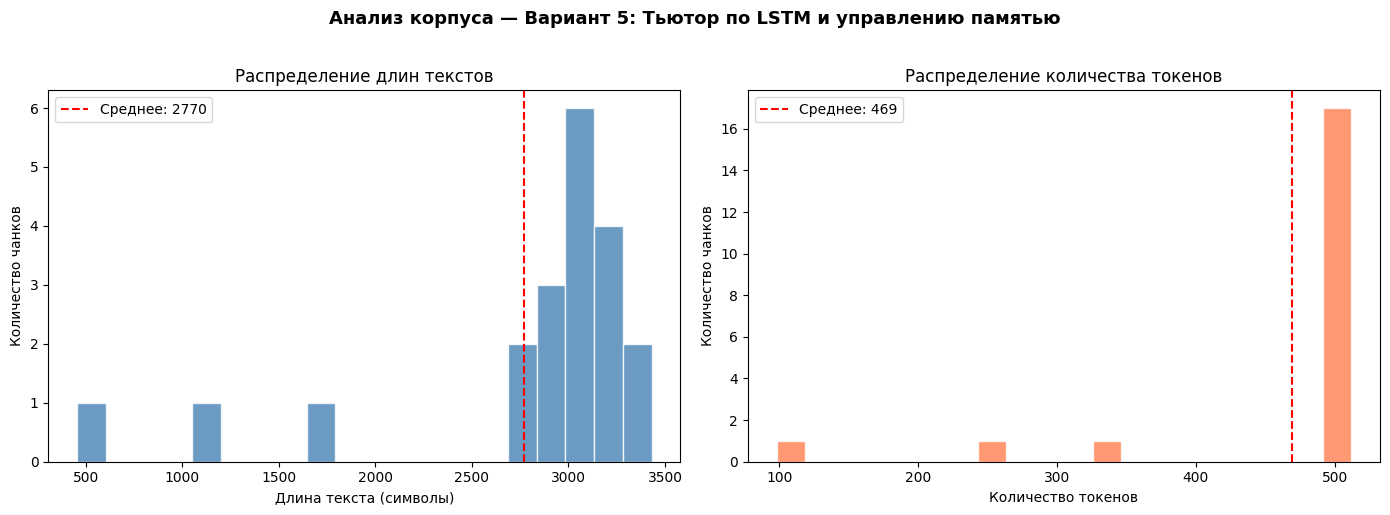

Гистограммы сохранены: dataset_analysis.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма длин текстов (в символах)
char_lengths = [len(t) for t in dataset["text"]]
mean_chars = np.mean(char_lengths)
axes[0].hist(char_lengths, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(mean_chars, color="red", linestyle="--", label=f"Среднее: {mean_chars:.0f}")
axes[0].set_xlabel("Длина текста (символы)")
axes[0].set_ylabel("Количество чанков")
axes[0].set_title("Распределение длин текстов")
axes[0].legend()

# Гистограмма количества токенов (по attention_mask)
token_counts = [sum(m) for m in dataset["attention_mask"]]
mean_tokens = np.mean(token_counts)
axes[1].hist(token_counts, bins=20, color="coral", edgecolor="white", alpha=0.8)
axes[1].axvline(mean_tokens, color="red", linestyle="--", label=f"Среднее: {mean_tokens:.0f}")
axes[1].set_xlabel("Количество токенов")
axes[1].set_ylabel("Количество чанков")
axes[1].set_title("Распределение количества токенов")
axes[1].legend()

plt.suptitle(
    f"Анализ корпуса — Вариант {config.variant}: {config.topic}",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig(config.plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Гистограммы сохранены: {config.plot_path}")

## 7. Сохранение датасета

In [18]:
# Сохранение Dataset на диск
dataset.save_to_disk(config.dataset_dir)

# Метаданные
info = {
    "variant": config.variant,
    "topic": config.topic,
    "keywords": config.keywords,
    "model": config.model_name,
    "num_sources": len(sources),
    "total_chars": sum(len(s["text"]) for s in sources),
    "num_chunks": len(all_chunks),
    "max_length": config.max_length,
    "chunk_size_words": config.chunk_size_words,
    "chunk_overlap_words": config.chunk_overlap_words,
}

info_path = os.path.join(config.dataset_dir, "info.json")
with open(info_path, "w", encoding="utf-8") as f:
    json.dump(info, f, ensure_ascii=False, indent=2)

print(f"Dataset сохранён: {config.dataset_dir}/")
print(f"Метаданные: {info_path}")

# Валидация: перезагрузка
reloaded = load_from_disk(config.dataset_dir)
assert len(reloaded) == len(dataset), "Размер после перезагрузки не совпадает"
assert reloaded.column_names == dataset.column_names, "Столбцы не совпадают"
print(f"Перезагрузка: OK ({len(reloaded)} примеров, столбцы: {reloaded.column_names})")

Saving the dataset (1/1 shards): 100%|██████████| 20/20 [00:00<00:00, 7833.96 examples/s]

Dataset сохранён: corpus_variant_5/
Метаданные: corpus_variant_5/info.json
Перезагрузка: OK (20 примеров, столбцы: ['text', 'input_ids', 'attention_mask'])


## 8. Системный промпт для LSTM-тьютора

In [19]:
SYSTEM_PROMPT = """Ты — LSTM-тьютор, экспертный помощник по архитектуре LSTM и управлению памятью в рекуррентных нейронных сетях.

Области твоей экспертизы:
1. Архитектура LSTM — структура ячейки, состояние ячейки, скрытое состояние
2. Forget gate (вентиль забывания) — механизм, формулы, инициализация
3. Input gate (входной вентиль) — механизм обновления, candidate state
4. Output gate (выходной вентиль) — формирование выхода
5. Long-term dependencies — захват долгосрочных зависимостей
6. Gradient flow — поток градиентов, vanishing/exploding gradient problem
7. Обучение LSTM — оптимизаторы, gradient clipping, dropout, инициализация
8. Сравнение с RNN и GRU — архитектурные различия, преимущества, ограничения

Правила ответа:
- Объясняй сначала интуицию, затем формулу, затем пример
- Используй аналогии для сложных концепций
- Приводи числовые примеры где возможно
- Отвечай на русском языке
"""

print("Системный промпт LSTM-тьютора:")
print("=" * 60)
print(SYSTEM_PROMPT)
print("=" * 60)

Системный промпт LSTM-тьютора:
Ты — LSTM-тьютор, экспертный помощник по архитектуре LSTM и управлению памятью в рекуррентных нейронных сетях.

Области твоей экспертизы:
1. Архитектура LSTM — структура ячейки, состояние ячейки, скрытое состояние
2. Forget gate (вентиль забывания) — механизм, формулы, инициализация
3. Input gate (входной вентиль) — механизм обновления, candidate state
4. Output gate (выходной вентиль) — формирование выхода
5. Long-term dependencies — захват долгосрочных зависимостей
6. Gradient flow — поток градиентов, vanishing/exploding gradient problem
7. Обучение LSTM — оптимизаторы, gradient clipping, dropout, инициализация
8. Сравнение с RNN и GRU — архитектурные различия, преимущества, ограничения

Правила ответа:
- Объясняй сначала интуицию, затем формулу, затем пример
- Используй аналогии для сложных концепций
- Приводи числовые примеры где возможно
- Отвечай на русском языке



## 9. Тестовый инференс

Тестирование базовой модели rugpt3small (без дообучения).  
**Примечание:** модель является базовой (pretrained), не instruction-tuned, поэтому ожидается продолжение текста, а не диалоговый ответ.

In [20]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=device,
)

prompts = [
    "LSTM расшифровывается как",
    "Вентиль забывания (forget gate) в LSTM нужен для",
    "Проблема затухающего градиента заключается в том, что",
    "Основное отличие LSTM от обычной RNN состоит в",
    "Для обучения LSTM-сети рекомендуется использовать",
]

print("Тестовый инференс (rugpt3small, базовая модель)")
print("=" * 60)

for i, prompt in enumerate(prompts, 1):
    result = generator(
        prompt,
        max_new_tokens=80,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        num_return_sequences=1,
        pad_token_id=tokenizer.eos_token_id,
    )
    generated = result[0]["generated_text"]
    print(f"\n--- Промпт {i} ---")
    print(f"Вход: {prompt}")
    print(f"Выход: {generated}")

print("\n" + "=" * 60)
print("Примечание: rugpt3small — базовая модель, обученная на общем русскоязычном корпусе.")
print("Генерация является продолжением текста, а не ответом на вопрос.")
print("Для получения качественных ответов по LSTM необходимо дообучение (fine-tuning).")

Device set to use mps


Тестовый инференс (rugpt3small, базовая модель)

--- Промпт 1 ---
Вход: LSTM расшифровывается как
Выход: LSTM расшифровывается как "Transformation Methods".  В дальнейшем эта расшифровка будет использоваться для определения возможности использования в медицине различных методов лечения.  В настоящее время существует большое количество различных методик, применяемых для лечения различных заболеваний.  Так, например, широко применяется методика, основанная на использовании специального теста.  При помощи данного теста можно определить, сколько времени необходимо для проведения процедуры.  Кроме того, существуют

--- Промпт 2 ---
Вход: Вентиль забывания (forget gate) в LSTM нужен для
Выход: Вентиль забывания (forget gate) в LSTM нужен для предотвращения рецидива заболевания.  Обычно для этого используют вентиляторы.  Вентиляторы можно заменить вентиляторами, которые установлены в автомобиле.  Для этого необходимо снять обшивку с автомобиля. 
 Вентилятор вентилятор 
 Вентилятор вентилятор 

## 10. Ответы на контрольные вопросы

### Вопрос 1. Что такое предметный корпус текстов и зачем он нужен?

Предметный корпус текстов — это структурированная коллекция текстовых документов, объединённых общей тематикой (в нашем случае — LSTM и управление памятью в RNN). Корпус необходим для дообучения (fine-tuning) языковой модели, чтобы она могла генерировать качественные ответы по конкретной предметной области. Без предметного корпуса базовая модель генерирует общие тексты, не содержащие специализированных знаний. Корпус должен быть достаточного объёма (≥50,000 символов), содержать информацию из нескольких источников (≥3) и покрывать все ключевые аспекты темы.

### Вопрос 2. Какую модель вы использовали и почему?

Использована модель **ai-forever/rugpt3small_based_on_gpt2** (125M параметров) — русскоязычная версия GPT-2 small, обученная на русскоязычных текстах. Выбор обусловлен несколькими факторами: (1) модель поддерживает русский язык, что соответствует языку корпуса; (2) размер 125M параметров позволяет работать на обычном оборудовании (в т.ч. на ноутбуке с Apple M4 Pro) без GPU-сервера; (3) архитектура GPT-2 хорошо подходит для задач генерации текста (causal language modeling); (4) модель свободно доступна через HuggingFace Hub.

### Вопрос 3. Как происходит токенизация и зачем нужны padding и truncation?

Токенизация — процесс преобразования текста в последовательность числовых идентификаторов (token IDs), понятных модели. Токенизатор rugpt3small использует BPE (Byte Pair Encoding), разбивая текст на подслова. **Truncation** (обрезка) необходима для ограничения длины входа максимальным размером, поддерживаемым моделью (512 токенов). Тексты длиннее max_length обрезаются. **Padding** (дополнение) необходим для формирования батчей: все последовательности в батче должны иметь одинаковую длину. Короткие последовательности дополняются специальным токеном (pad_token) до max_length. **Attention mask** — бинарный вектор, указывающий модели, какие позиции содержат реальные токены (1), а какие — padding (0).

### Вопрос 4. Что такое чанкинг и зачем нужно перекрытие (overlap)?

Чанкинг — разбиение длинного текста на фрагменты (чанки) фиксированного размера, пригодные для обработки моделью. В данной работе размер чанка — 400 слов (~512 токенов). **Перекрытие** (overlap = 50 слов) означает, что последние 50 слов предыдущего чанка включаются в начало следующего. Это необходимо для сохранения контекста на границах чанков: без перекрытия модель теряет связность информации на стыках фрагментов. Перекрытие обеспечивает, что каждое предложение присутствует хотя бы в одном чанке полностью, а не разрезанным пополам.

### Вопрос 5. Почему базовая модель плохо справляется с предметными вопросами?

Базовая модель rugpt3small обучена на общем русскоязычном корпусе и не имеет специализированных знаний об LSTM. Она генерирует продолжение текста на основе статистических закономерностей, выученных из обучающих данных. Для предметных вопросов об LSTM модель может: (1) генерировать грамматически правильный, но фактически неверный текст; (2) уходить от темы; (3) повторять общие фразы без глубины. Для качественных ответов необходимо дообучение (fine-tuning) на предметном корпусе, что позволит модели «выучить» специализированную терминологию, формулы и взаимосвязи между концепциями LSTM.

### Вопрос 6. Что такое HuggingFace Dataset и каковы его преимущества?

HuggingFace Dataset — формат хранения данных из библиотеки `datasets`, оптимизированный для машинного обучения. Преимущества: (1) **эффективность памяти** — данные хранятся в формате Apache Arrow, обеспечивающем zero-copy чтение и memory-mapping (данные загружаются с диска по мере необходимости, не занимая всю RAM); (2) **удобство обработки** — метод `.map()` позволяет применять функции к данным в батчевом режиме с автоматическим кэшированием; (3) **стандартизация** — единый интерфейс для работы с данными, совместимый с Trainer и другими компонентами HuggingFace; (4) **сохранение и загрузка** — `save_to_disk()` / `load_from_disk()` обеспечивают персистентность; (5) **интеграция** — бесшовная работа с токенизаторами и моделями HuggingFace.

### Вопрос 7. Какие метрики и визуализации использованы для анализа корпуса?

Для анализа корпуса использованы: (1) **статистика по источникам** — количество источников, объём каждого в символах, общий объём; (2) **статистика по чанкам** — количество чанков, минимальная, максимальная и средняя длина в словах; (3) **гистограмма длин текстов** (в символах) — показывает распределение размеров чанков и позволяет оценить однородность разбиения; (4) **гистограмма количества токенов** (по attention_mask) — показывает, сколько реальных (не-padding) токенов содержит каждый пример, позволяя оценить эффективность использования max_length. На обеих гистограммах отмечена средняя линия. Визуализации сохранены в файл `dataset_analysis.png`.